In [5]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

### Histogram of Genome Counts per Bin

In [6]:
binary = pd.read_csv('AllBiomesBinaryFinal.txt', delimiter = '\t', index_col= 0) #this is every genome, EC, and the biome it is in. Cresten Concatanated each dataframe. 
# binary.columns 
binary.head()


,1_1_1_1,1_1_1_2,1_1_1_3,1_1_1_4,1_1_1_5,1_1_1_6,1_1_1_7,1_1_1_8,1_1_1_9,1_1_1_10,...,7_6_2_8,7_6_2_9,7_6_2_10,7_6_2_11,7_6_2_12,7_6_2_13,7_6_2_14,7_6_2_15,7_6_2_16,Biome
Name_of_Genome,,,,,,,,,,,,,,,,,,,,,
3300056625_228,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,ActivatedSludge
3300056625_197,0,0,1,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,ActivatedSludge
3300055001_136,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,ActivatedSludge
3300055001_94,1,1,1,0,0,0,0,0,0,0,...,1,0,1,1,0,0,0,0,0,ActivatedSludge
3300056626_306,0,1,1,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,ActivatedSludge


In [7]:
binary.index #index is our genomes
binary['Biome'] = binary['Biome'].astype('category')
# binary.dtypes


In [8]:
sums = binary.loc[ :, binary.columns != 'Biome']
sums = sums.sum()
sums

1_1_1_1     3586
1_1_1_2     1557
1_1_1_3     4531
1_1_1_4      483
1_1_1_5        0
            ... 
7_6_2_12     138
7_6_2_13     734
7_6_2_14    1956
7_6_2_15     201
7_6_2_16     612
Length: 8269, dtype: int64

In [9]:
counts = binary['Biome'].value_counts()
counts = pd.DataFrame(counts)
counts = counts.rename(index={'ActivatedSludge': 'Activated Sludge', 'BulkSoil': 'Bulk Soil', 'LakeSediment': 'Lake Sediment', 'CowRumen':'Cow Rumen', 'RiverSediment':'River Sediment'})
counts = counts.rename(columns={'count': 'Total Genomes'})
counts = counts.reset_index()
counts

,Biome,Total Genomes
0,Bulk Soil,2267
1,Lake Sediment,2186
2,Activated Sludge,1374
3,Cow Rumen,1293
4,River Sediment,633


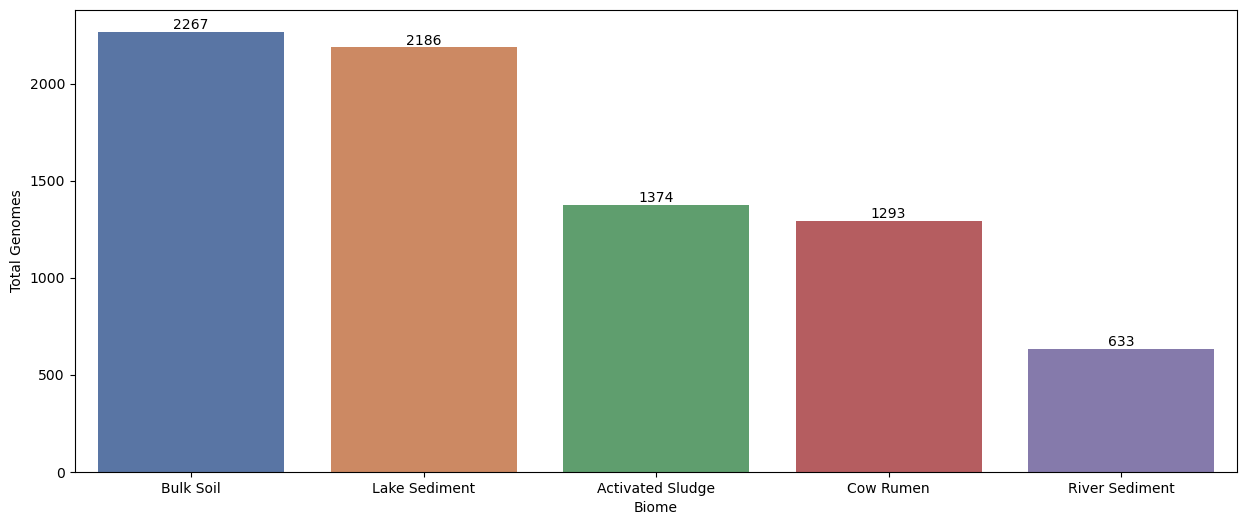

In [10]:
plt.figure(figsize=(15,6))
ax = sns.barplot(x='Biome', y='Total Genomes', data = counts, palette = 'deep')
for i in ax.containers:
    ax.bar_label(i,)
plt.show()

In [ ]:
column_sums = binary.groupby(by='Biome', observed=False).sum()
ec_sums = pd.DataFrame(column_sums)
clean = ec_sums.rename(index={'ActivatedSludge': 'Activated Sludge', 'BulkSoil': 'Bulk Soil', 'LakeSediment': 'Lake Sediment', 'CowRumen':'Cow Rumen', 'RiverSediment':'River Sediment'})
# for col in clean.columns:
#     if clean[col].sum()<=100:
#         del clean[col]
# print(ec_sums)
clean

# test = clean.loc['Activated Sludge'].sum()
# test

/var/folders/lb/grx8d3_s71g7q4hk56bqxj6c0000gn/T/ipykernel_20252/3649890525.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.000599785478186634' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  clean.loc['Activated Sludge'] = (clean.loc['Activated Sludge'] / as_sum)
/var/folders/lb/grx8d3_s71g7q4hk56bqxj6c0000gn/T/ipykernel_20252/3649890525.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.0005443308597654854' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  clean.loc['Activated Sludge'] = (clean.loc['Activated Sludge'] / as_sum)
/var/folders/lb/grx8d3_s71g7q4hk56bqxj6c0000gn/T/ipykernel_20252/3649890525.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.0010959583798495428' has d

1.0

In [ ]:
as_sum = clean.loc['Activated Sludge'].sum()
clean.loc['Activated Sludge'] = (clean.loc['Activated Sludge'] / as_sum) 
as_sum = clean.loc['Activated Sludge'].sum()
clean.loc['Activated Sludge'] = (clean.loc['Activated Sludge'] / as_sum) 
as_sum = clean.loc['Activated Sludge'].sum()
clean.loc['Activated Sludge'] = (clean.loc['Activated Sludge'] / as_sum) 
as_sum = clean.loc['Activated Sludge'].sum()
clean.loc['Activated Sludge'] = (clean.loc['Activated Sludge'] / as_sum) 
as_sum = clean.loc['Activated Sludge'].sum()
clean.loc['Activated Sludge'] = (clean.loc['Activated Sludge'] / as_sum) 

<Axes: ylabel='Biome'>

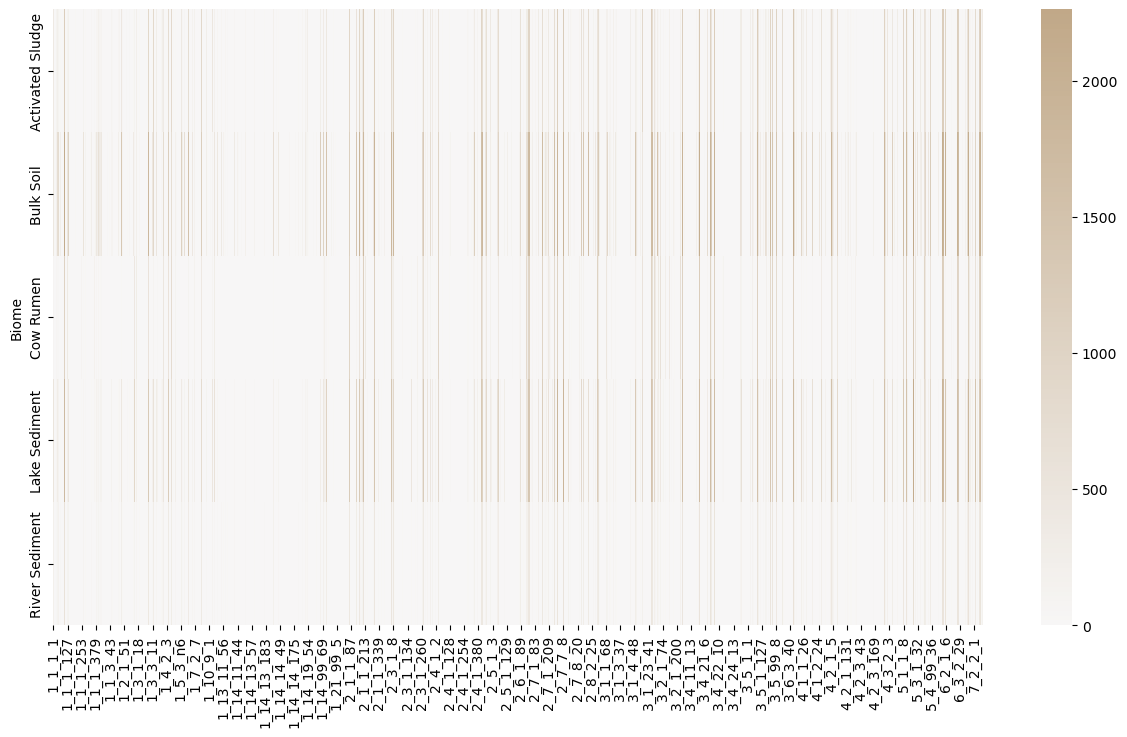

In [12]:
plt.figure(figsize=(15, 8))
color = sns.diverging_palette(220, 50, as_cmap=True)
sns.heatmap(data=clean, alpha = 0.6, center=0, cmap=color)